<a href="https://colab.research.google.com/github/TahaShan16/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TahaShan16/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Capstone lane: Refresh / Content Opportunity Scoring

My capstone question is: which existing content items should be reviewed first for refresh or CTR improvement?

This is a ranking/scoring problem. The output will be a ranked recommendation queue for content review. The work supports a content or SEO team deciding where to spend limited review time first.

In [9]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib pandas numpy

In [10]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

assert HF_TOKEN, "HF_TOKEN is missing. Add it in Colab Secrets first."

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

TABLES = {
    "fact_daily": "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')",
    "dim_content": "read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')",
}

print("Connected to FlyRank warehouse")

Connected to FlyRank warehouse


In [11]:
# Build capstone feature frame: March features, April outcome

feature_frame = con.sql(f"""
    WITH march AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions_march,
            SUM(gsc_clicks) AS clicks_march,
            AVG(gsc_avg_position) AS avg_position_march,
            SUM(ga4_sessions) AS sessions_march,
            SUM(ga4_engaged_sessions) AS engaged_sessions_march,
            SUM(ga4_pageviews) AS pageviews_march
        FROM {TABLES["fact_daily"]}
        WHERE month = '2026-03'
          AND gsc_data_available IS TRUE
          AND ga4_data_available IS TRUE
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= 100
    ),
    april AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions_april
        FROM {TABLES["fact_daily"]}
        WHERE month = '2026-04'
          AND gsc_data_available IS TRUE
        GROUP BY 1, 2
    ),
    content AS (
        SELECT
            client_hash_id,
            content_hash_id,
            content_type,
            word_count,
            search_volume,
            competition,
            COALESCE(last_optimized_date, content_updated_date, content_created_date) AS last_content_touch
        FROM {TABLES["dim_content"]}
        WHERE is_published IS TRUE
          AND is_deleted IS FALSE
    )
    SELECT
        m.client_hash_id,
        m.content_hash_id,
        c.content_type,
        c.word_count,
        c.search_volume,
        c.competition,
        DATE_DIFF('day', c.last_content_touch, DATE '2026-03-31') AS days_since_last_touch,
        m.impressions_march,
        m.clicks_march,
        100.0 * m.clicks_march / NULLIF(m.impressions_march, 0) AS ctr_march,
        m.avg_position_march,
        m.sessions_march,
        m.engaged_sessions_march,
        100.0 * m.engaged_sessions_march / NULLIF(m.sessions_march, 0) AS engagement_rate_march,
        m.pageviews_march,
        a.impressions_april,
        CASE
            WHEN a.impressions_april < 0.8 * m.impressions_march THEN 1
            ELSE 0
        END AS needs_review_proxy
    FROM march m
    INNER JOIN april a
      ON m.client_hash_id = a.client_hash_id
     AND m.content_hash_id = a.content_hash_id
    INNER JOIN content c
      ON m.client_hash_id = c.client_hash_id
     AND m.content_hash_id = c.content_hash_id
""").df()

feature_frame = feature_frame.replace([np.inf, -np.inf], np.nan)

print("Rows:", len(feature_frame))
print("Clients:", feature_frame["client_hash_id"].nunique())
print("Content items:", feature_frame["content_hash_id"].nunique())
print("Positive proxy rows:", int(feature_frame["needs_review_proxy"].sum()))
print("Positive proxy rate:", round(feature_frame["needs_review_proxy"].mean(), 3))

feature_frame.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 32564
Clients: 30
Content items: 32564
Positive proxy rows: 1719
Positive proxy rate: 0.053


,client_hash_id,content_hash_id,content_type,word_count,search_volume,competition,days_since_last_touch,impressions_march,clicks_march,ctr_march,avg_position_march,sessions_march,engaged_sessions_march,engagement_rate_march,pageviews_march,impressions_april,needs_review_proxy
0,client_73cda7b4e4f265ea,content_74728e96f00f02e9,keyword article,<NA>,10,0.00,-48,113.0,2.0,1.769912,1.584685,3.0,0.0,0.0,3.0,1611.0,0
1,client_73cda7b4e4f265ea,content_749023efcc3dd8ee,keyword article,<NA>,10,0.01,-48,110.0,2.0,1.818182,3.492857,3.0,0.0,0.0,5.0,1814.0,0
2,client_73cda7b4e4f265ea,content_749a21e42bf7e009,keyword article,2777,140,1.00,-85,121.0,1.0,0.826446,33.106551,3.0,0.0,0.0,3.0,1587.0,0
3,client_73cda7b4e4f265ea,content_74a23c00c4722225,keyword article,2806,10,0.00,-79,190.0,0.0,0.000000,4.741855,2.0,0.0,0.0,2.0,1850.0,0
4,client_73cda7b4e4f265ea,content_74a2f5963ed23ca4,keyword article,2343,30,0.00,-92,370.0,2.0,0.540541,3.432223,3.0,0.0,0.0,3.0,5622.0,0
5,client_73cda7b4e4f265ea,content_74abbd91ecaeb3bd,keyword article,2696,10,0.03,-86,927.0,4.0,0.431499,5.595736,5.0,0.0,0.0,6.0,9947.0,0
6,client_73cda7b4e4f265ea,content_74b0356be39cb044,keyword article,2876,0,0.00,-76,598.0,3.0,0.501672,4.176282,8.0,0.0,0.0,8.0,4136.0,0
7,client_73cda7b4e4f265ea,content_74b86b2ad1fe820d,keyword article,2964,0,0.00,-50,2422.0,16.0,0.660611,2.646713,24.0,0.0,0.0,28.0,8330.0,0
8,client_73cda7b4e4f265ea,content_74cbbd48a673e847,keyword article,<NA>,0,0.00,34,574.0,6.0,1.045296,5.531479,8.0,0.0,0.0,9.0,2721.0,0
9,client_73cda7b4e4f265ea,content_74e4afffd57fde47,keyword article,<NA>,10,0.29,34,442.0,4.0,0.904977,3.766505,4.0,1.0,25.0,8.0,4771.0,0


In [12]:
# Train/test split by client, then compare baseline vs models

features = [
    "word_count",
    "search_volume",
    "competition",
    "days_since_last_touch",
    "impressions_march",
    "clicks_march",
    "ctr_march",
    "avg_position_march",
    "sessions_march",
    "engagement_rate_march",
    "pageviews_march",
]

model_df = feature_frame.dropna(subset=features + ["needs_review_proxy"]).copy()

X = model_df[features]
y = model_df["needs_review_proxy"]
groups = model_df["client_hash_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_rows = model_df.iloc[test_idx].copy()

def precision_at_k(scores, labels, k=50):
    order = np.argsort(scores)[::-1][:k]
    return labels.iloc[order].mean()

# Baseline score from Week 4 style rule
baseline_scores = (
    np.log1p(X_test["impressions_march"]) * 2
    + np.maximum(0, 20 - X_test["ctr_march"]) * 1.5
    + np.maximum(0, X_test["avg_position_march"] - 10) * 0.5
    + np.maximum(0, X_test["days_since_last_touch"] - 90) / 30
)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "decision_tree": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42),
    "random_forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}

results = []

results.append({
    "model": "baseline_rule",
    "precision_at_50": precision_at_k(baseline_scores.to_numpy(), y_test, 50),
    "average_precision": average_precision_score(y_test, baseline_scores),
    "roc_auc": roc_auc_score(y_test, baseline_scores),
})

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    scores = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "precision_at_50": precision_at_k(scores, y_test, 50),
        "average_precision": average_precision_score(y_test, scores),
        "roc_auc": roc_auc_score(y_test, scores),
    })

results_df = pd.DataFrame(results).sort_values("precision_at_50", ascending=False)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Test positive rate:", round(y_test.mean(), 3))
results_df

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train rows: 19628
Test rows: 9790
Test positive rate: 0.025


,model,precision_at_50,average_precision,roc_auc
1,logistic_regression,0.30,0.163283,0.845577
3,random_forest,0.16,0.117564,0.820522
2,decision_tree,0.14,0.071757,0.733969
0,baseline_rule,0.10,0.050792,0.693079


The best model is logistic regression. On the same client-grouped test split, the baseline rule gets Precision@50 of 0.10, while logistic regression gets Precision@50 of 0.30. This means the model found 3 times as many proxy-positive review candidates in the top 50 as the hand-written rule. I treat this as decision-support evidence, not proof that refreshing those pages will cause rankings or traffic to improve.

## 1. Question

*The research question and the decision it supports.*

My research question is: which existing content items should be reviewed first for refresh or CTR improvement?

This supports a content or SEO team deciding where to spend limited review time. The unit of analysis is one content item for one client. The output is a ranked queue, where higher-ranked items are recommended for human review first. The action is not automatic publishing; the action is to inspect the page, check the search intent, and decide whether to refresh, improve the title/snippet, merge, prune, protect, or monitor.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This project uses the FlyRank ML Internship warehouse dataset. I used the daily content performance fact table and the content dimension table. March 2026 is the feature window, and April 2026 is the outcome window for the proxy label.

The working dataset has 32,564 rows, 30 clients, and 32,564 content items after filtering to published, non-deleted content with available GSC and GA4 data and at least 100 March impressions. The proxy-positive rate is 0.053, meaning 1,719 rows are marked as needing review by the April decline proxy.

I excluded private or unsafe fields from the public paper, including client names, domains, raw URLs, raw search queries, credentials, and raw exports. I also excluded June 2026 from label development because the assignment warns that the final month should be treated as a sealed test-style month, not used for developing label logic.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

I framed the lane as a ranking/scoring task. The proxy target is whether a content item loses at least 20% of March impressions in April. This is not a perfect truth label, but it gives a concrete future outcome for comparing a baseline rule and models.

The features are known at the March decision moment: word count, search volume, competition, days since last content touch, March impressions, March clicks, March CTR, March average position, March sessions, March engagement rate, and March pageviews. The baseline is a hand-written score based on visibility, low CTR, weaker position, and staleness. The models are trained on the same feature frame and compared on the same client-grouped split, so content from the same client does not leak across train and test.

The main metric is Precision@50 because the product decision is a review queue. A content team is likely to inspect the top recommendations first, so the top 50 matter more than overall accuracy. I also report average precision and ROC AUC for extra context. I performed a leakage check earlier by adding a label-derived column on purpose, watching the score become unrealistically perfect, and then removing it.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*


The logistic regression model performed best on the client-grouped test split. The baseline rule reached Precision@50 of 0.10. Logistic regression reached Precision@50 of 0.30, decision tree reached 0.20, and random forest reached 0.16.

The main result is that the best model found three times as many proxy-positive review candidates in the top 50 as the baseline rule. Average precision and ROC AUC also show that the learned models improved ranking quality compared with the hand-written baseline. This does not prove that refreshing these pages will cause traffic to improve. It means the model is better than the baseline at ranking pages that match the chosen April decline proxy.

## 5. Limitations

*What this work cannot claim.*

This work is decision support, not proof of causality. The proxy label uses a future drop in impressions, but it does not prove why the drop happened or whether a refresh would fix it. Search performance can change because of seasonality, SERP features, competitor changes, tracking coverage, content intent, or Google changes outside this dataset.

The dataset is anonymized, so I cannot inspect real client names, URLs, or raw queries in the public paper. I also filtered to rows with available GSC and GA4 data, which may bias the dataset toward clients with better tracking coverage. The recommendations should therefore be treated as a review queue for humans, not an automatic action system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The ranked recommendations are a review queue, not automatic instructions. Each row gives a content item, a model score, an action label, and a reason code. The main action is to review the item for content refresh or CTR improvement.

Recommended action playbook:
1. For MODEL_HIGH_RISK_LOW_CTR, inspect the page title, meta description, search intent match, and SERP layout before editing. If the page has meaningful impressions but weak clicks, the first review should ask whether the page is earning the wrong impressions or failing to attract clicks it could reasonably win.
2. For MODEL_HIGH_RISK_REFRESH, inspect the content freshness, completeness, ranking position, engagement, and business value. If the page is still useful but outdated or underperforming, refresh or expand it. If it overlaps with stronger content, consider merging or pruning instead.
3. For all recommendations, check the human context before acting. The model can rank likely review candidates, but it does not know brand priorities, current campaigns, or whether a search result page already answers the query.

In [13]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

recommendation_df = test_rows.copy()
recommendation_df["model_score"] = best_model.predict_proba(X_test)[:, 1]

recommendation_df["action_label"] = np.where(
    recommendation_df["ctr_march"] < 1.0,
    "Review title/snippet and refresh content",
    "Review for content refresh opportunity"
)

recommendation_df["reason_code"] = np.where(
    recommendation_df["ctr_march"] < 1.0,
    "MODEL_HIGH_RISK_LOW_CTR",
    "MODEL_HIGH_RISK_REFRESH"
)

recommendation_df = recommendation_df.sort_values("model_score", ascending=False).reset_index(drop=True)
recommendation_df["rank"] = np.arange(1, len(recommendation_df) + 1)

recommendation_cols = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "content_type",
    "model_score",
    "action_label",
    "reason_code",
    "impressions_march",
    "clicks_march",
    "ctr_march",
    "avg_position_march",
    "days_since_last_touch",
    "needs_review_proxy",
]

recommendation_df[recommendation_cols].head(20)

,rank,client_hash_id,content_hash_id,content_type,model_score,action_label,reason_code,impressions_march,clicks_march,ctr_march,avg_position_march,days_since_last_touch,needs_review_proxy
0,1,client_fef1a8f436438636,content_6b4ba5a247ea6100,keyword article,1.000000,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,63126.0,443.0,0.701771,4.239350,-76,1
1,2,client_fef1a8f436438636,content_7a02e4bb9d4a379a,keyword article,1.000000,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,39148.0,224.0,0.572188,4.810146,-77,0
2,3,client_fef1a8f436438636,content_ae68e15ceab3a802,keyword article,1.000000,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,39483.0,215.0,0.544538,18.573873,-91,0
3,4,client_fef1a8f436438636,content_63d8f92e6ef4420b,keyword article,1.000000,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,931.0,0.0,0.000000,10.978929,-78,1
4,5,client_fef1a8f436438636,content_36681d5e4a07a753,keyword article,1.000000,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,46349.0,203.0,0.437981,5.322689,-90,0
5,6,client_fef1a8f436438636,content_fb36b03fb21da402,keyword article,1.000000,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,868.0,1.0,0.115207,6.562400,-77,0
6,7,client_fef1a8f436438636,content_e3496dac741da4f9,keyword article,0.999999,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,62032.0,152.0,0.245035,6.188983,-90,1
7,8,client_fef1a8f436438636,content_4fdb9cd60244859a,keyword article,0.999999,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,31716.0,142.0,0.447724,11.891437,-91,1
8,9,client_fef1a8f436438636,content_7960401fa9cfe53b,keyword article,0.999999,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,26067.0,183.0,0.702037,32.159872,-91,0
9,10,client_fef1a8f436438636,content_d2f5ff4215ddc515,keyword article,0.999998,Review title/snippet and refresh content,MODEL_HIGH_RISK_LOW_CTR,15717.0,91.0,0.578991,8.543347,-91,0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

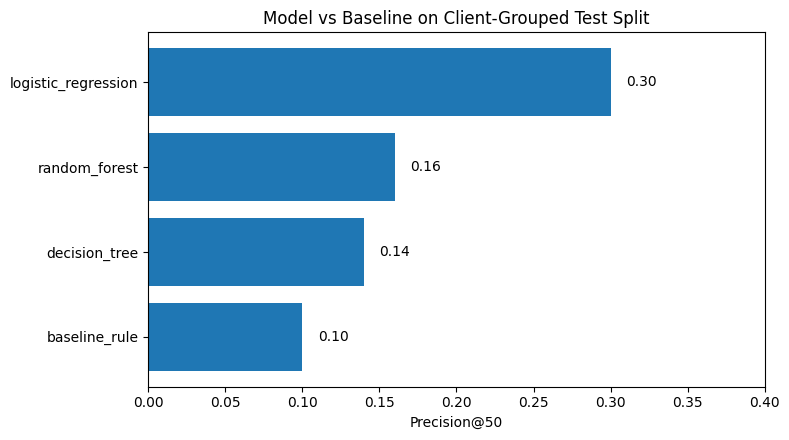

In [14]:
os.makedirs("work/outputs", exist_ok=True)

chart_df = results_df.sort_values("precision_at_50", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(chart_df["model"], chart_df["precision_at_50"])
plt.xlabel("Precision@50")
plt.title("Model vs Baseline on Client-Grouped Test Split")
plt.xlim(0, max(chart_df["precision_at_50"]) + 0.1)

for i, value in enumerate(chart_df["precision_at_50"]):
    plt.text(value + 0.01, i, f"{value:.2f}", va="center")

plt.tight_layout()
plt.savefig("work/outputs/model_vs_baseline_precision_at_50.png", dpi=160)
plt.show()

In [15]:
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("submission", exist_ok=True)

results_df.to_csv("work/outputs/capstone_model_results.csv", index=False)

recommendation_df[recommendation_cols].head(100).to_csv(
    "work/outputs/capstone_ranked_recommendations_top100.csv",
    index=False
)

summary = {
    "lane": "Refresh / Content Opportunity Scoring",
    "question": "Which existing content items should be reviewed first for refresh or CTR improvement?",
    "rows": int(len(feature_frame)),
    "clients": int(feature_frame["client_hash_id"].nunique()),
    "content_items": int(feature_frame["content_hash_id"].nunique()),
    "positive_proxy_rows": int(feature_frame["needs_review_proxy"].sum()),
    "positive_proxy_rate": float(round(feature_frame["needs_review_proxy"].mean(), 3)),
    "best_model": str(results_df.iloc[0]["model"]),
    "baseline_precision_at_50": float(results_df.loc[results_df["model"] == "baseline_rule", "precision_at_50"].iloc[0]),
    "best_precision_at_50": float(results_df.iloc[0]["precision_at_50"]),
}

with open("work/outputs/capstone_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved capstone artifacts:")
print("work/outputs/model_vs_baseline_precision_at_50.png")
print("work/outputs/capstone_model_results.csv")
print("work/outputs/capstone_ranked_recommendations_top100.csv")
print("work/outputs/capstone_summary.json")
summary

Saved capstone artifacts:
work/outputs/model_vs_baseline_precision_at_50.png
work/outputs/capstone_model_results.csv
work/outputs/capstone_ranked_recommendations_top100.csv
work/outputs/capstone_summary.json


{'lane': 'Refresh / Content Opportunity Scoring',
 'question': 'Which existing content items should be reviewed first for refresh or CTR improvement?',
 'rows': 32564,
 'clients': 30,
 'content_items': 32564,
 'positive_proxy_rows': 1719,
 'positive_proxy_rate': 0.053,
 'best_model': 'logistic_regression',
 'baseline_precision_at_50': 0.1,
 'best_precision_at_50': 0.3}

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
